Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import random
import os

# Data Source
import yfinance as yf

# Machine Learning
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
CONFIG = {
    "TICKER": "NVDA",
    "LOOKBACK_DAYS": 60,
    "TEST_SIZE": 0.2,
    "SEED": 42,
    "EPOCHS": 100,  
    "BATCH_SIZE": 32
}

In [3]:
# Set reproducibility to ensure consistent results across runs 
def set_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(CONFIG["SEED"])
plt.style.use('ggplot')

Data Loading & Preprocessing

In [4]:
# Download historical data from Yahoo Finance
def load_data(ticker, period="10y"):
    print(f"Downloading data for {ticker}...")
    df = yf.download(ticker, period=period, auto_adjust=True)

    # Ensures to only use the 'Close' column and flatten multi-index if present
    if isinstance(df.columns, pd.MultiIndex):
        df = df['Close']
    
    data = df[[ticker]].rename(columns={ticker: 'Close'}) if isinstance(df, pd.DataFrame) else df.to_frame(name='Close')
    return data

In [5]:
# Split data into Train/Test chronologically and scale it.
# Scaler is fit only on training data to prevent leakage.
def preprocess_data(data, test_size=0.2):
    split_idx = int(len(data) * (1 - test_size))
    
    train_data = data.iloc[:split_idx].values
    test_data = data.iloc[split_idx:].values
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    # Fit on Train, Transform Train and Test
    scaled_train = scaler.fit_transform(train_data)
    
    # For testing, the last 'lookback' days is required from train to predict the first test day
    dataset_total = pd.concat((data.iloc[:split_idx]['Close'], data.iloc[split_idx:]['Close']), axis=0)
    inputs = dataset_total[len(dataset_total) - len(test_data) - CONFIG["LOOKBACK_DAYS"]:].values
    inputs = inputs.reshape(-1, 1)
    scaled_test = scaler.transform(inputs)
    
    return scaled_train, scaled_test, scaler, test_data

In [6]:
df = load_data(CONFIG["TICKER"])
print(f"Loaded {len(df)} rows.")

scaled_train, scaled_test, scaler, true_test_prices = preprocess_data(df, CONFIG["TEST_SIZE"])

[*********************100%***********************]  1 of 1 completed

Loaded 2515 rows.


Feature Engineering (Sequence Generation)

In [7]:
# Create Sequences for LSTM; X (features) and y (targets) for time series.
def create_sequences(dataset, lookback):
    X, y = [], []
    for i in range(lookback, len(dataset)):
        X.append(dataset[i-lookback:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

# Training Sequences
X_train, y_train = create_sequences(scaled_train, CONFIG["LOOKBACK_DAYS"])

# Testing Sequences
X_test, y_test = create_sequences(scaled_test, CONFIG["LOOKBACK_DAYS"])

# Reshape for LSTM
X_train_lstm = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Train Shape: (1952, 60), Test Shape: (503, 60)


Train traditional ML Models

In [8]:
results = {}

# Linear Regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds_scaled = lr_model.predict(X_test)
results['Linear Regression'] = scaler.inverse_transform(lr_preds_scaled.reshape(-1, 1))

# Random Forest
print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=CONFIG["SEED"], n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds_scaled = rf_model.predict(X_test)
results['Random Forest'] = scaler.inverse_transform(rf_preds_scaled.reshape(-1, 1))

Training Linear Regression...
Training Random Forest...


Train LSTM Model

In [9]:
def build_lstm(input_shape):
    model = Sequential([
        tf.keras.layers.InputLayer(shape=input_shape),
        # Layer 1
        LSTM(units=50, return_sequences=True),
        Dropout(0.2),
        # Layer 2
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        # Output Layer
        Dense(units=1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

print("Training LSTM...")
lstm_model = build_lstm((X_train_lstm.shape[1], 1))

early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=CONFIG["EPOCHS"],
    batch_size=CONFIG["BATCH_SIZE"],
    callbacks=[early_stop],
    verbose=1
)

lstm_preds_scaled = lstm_model.predict(X_test_lstm)
results['LSTM'] = scaler.inverse_transform(lstm_preds_scaled)

Training LSTM...
Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0110
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0019
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0017
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0018
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0018
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0014
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0013
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0013
Epoch 9/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0013
Epoch 10/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0011
Epoch 11/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0012
Epoch 12/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0013
Epoch 13/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0012
Epoch 14/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0011
Epoch 15/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 

Evaluation & Visualization


 Model Performance:
               Model       RMSE        MAE
0  Linear Regression   3.989448   2.950292
1      Random Forest  85.900559  76.828079
2               LSTM  27.837731  22.807059


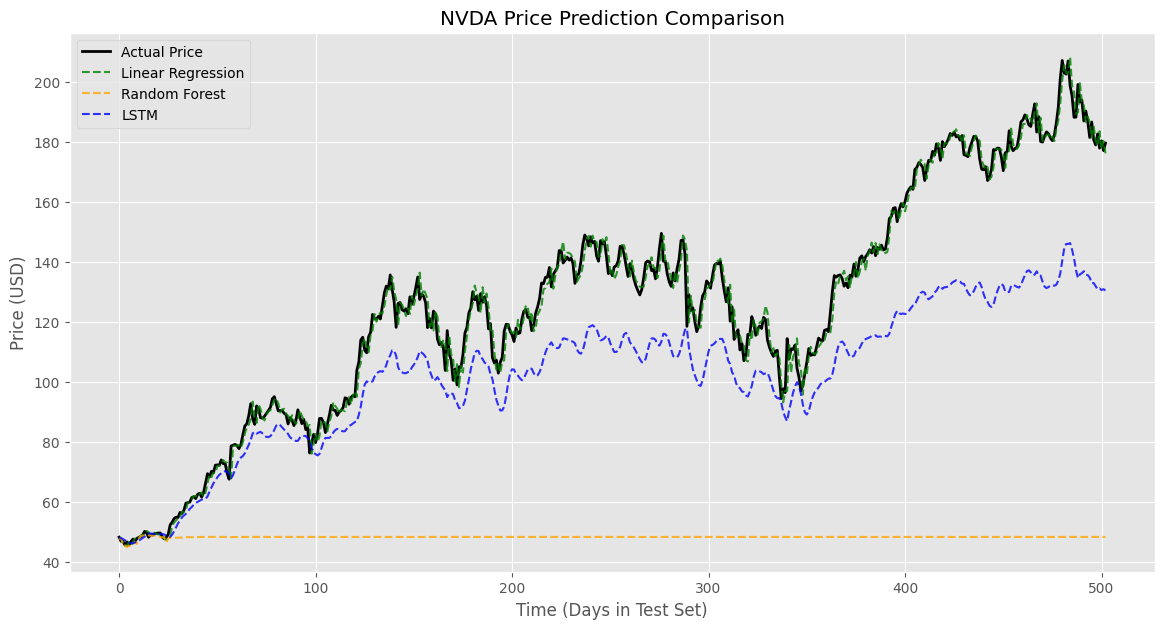

In [10]:
def evaluate_models(true_values, predictions_dict):
    metrics = []
    for name, preds in predictions_dict.items():
        rmse = np.sqrt(mean_squared_error(true_values, preds))
        mae = mean_absolute_error(true_values, preds)
        metrics.append({"Model": name, "RMSE": rmse, "MAE": mae})
    
    return pd.DataFrame(metrics)

# Metrics Table
metrics_df = evaluate_models(true_test_prices, results)
print("\n Model Performance:")
print(metrics_df)

# Visualization
plt.figure(figsize=(14, 7))
plt.plot(true_test_prices, label="Actual Price", color='black', linewidth=2)

colors = ['green', 'orange', 'blue']
for (name, preds), color in zip(results.items(), colors):
    plt.plot(preds, label=name, color=color, linestyle='--', alpha=0.8)

plt.title(f"{CONFIG['TICKER']} Price Prediction Comparison")
plt.xlabel("Time (Days in Test Set)")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

Model Selection & Saving

In [11]:
import os
import joblib
import tensorflow as tf

# Get RMSE scores from the metrics DataFrame
rmse_dict = dict(zip(metrics_df['Model'], metrics_df['RMSE']))

# Define model candidates
candidates = {
    "Linear Regression": {"model": lr_model, "rmse": rmse_dict['Linear Regression']},
    "Random Forest": {"model": rf_model, "rmse": rmse_dict['Random Forest']},
    "LSTM": {"model": lstm_model, "rmse": rmse_dict['LSTM']}
}

# Select best performing model
best_score = float('inf')
best_model_name = None
best_model_object = None

print("Model Selection Analysis")
for name, data in candidates.items():
    print(f"Model: {name:<20} | RMSE: ${data['rmse']:.4f}")
    if data['rmse'] < best_score:
        best_score = data['rmse']
        best_model_name = name
        best_model_object = data['model']

print(f"\nBest Performing Model: {best_model_name} (RMSE: ${best_score:.4f})")

# Save models intelligently
models_dir = os.path.join('..', 'models')
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

# Define paths
pkl_path = os.path.join(models_dir, "best_model.pkl")
keras_path = os.path.join(models_dir, "best_model.keras")

# Clean up old models to prevent confusion (only one champion can exist)
if os.path.exists(pkl_path): os.remove(pkl_path)
if os.path.exists(keras_path): os.remove(keras_path)

# Save based on model type
if isinstance(best_model_object, tf.keras.Model):
    print(f"Saving {best_model_name} in Keras format...")
    best_model_object.save(keras_path)
else:
    print(f"Saving {best_model_name} in Pkl format...")
    joblib.dump(best_model_object, pkl_path)

# Save the scaler 
joblib.dump(scaler, os.path.join(models_dir, "scaler.pkl"))
print("Pipeline Saved Successfully.")

Model Selection Analysis
Model: Linear Regression    | RMSE: $3.9894
Model: Random Forest        | RMSE: $85.9006
Model: LSTM                 | RMSE: $27.8377

Best Performing Model: Linear Regression (RMSE: $3.9894)
Saving Linear Regression in Pkl format...
Pipeline Saved Successfully.
